# xsmurf demo validation — 2D fBm calibration with τ(q,a), h(q,a), D(q,a) plateau fitter

Mirrors `xsmurf/doc/templates/testXsmurf_scalar2d/scr_gaussian.tcl` recipe:
1. Synthesize 2D fBm at known Hurst H via Fourier-domain radial-spectrum filter (matches `ibro` in `image/generator.c`).
2. CWT (g1 wavelet, gaussian first-derivative).
3. NMS extrema via `xsm.wtmm2d`.
4. Chain across scales via `chain_and_extract` (greedy / xsmurf protocol).
5. Partition function via `xsmurf_wrapper.partition.compute_HD_per_scale` — same code as xsmurf's `pf compute`.
6. **Interactive plateau fitter** showing τ(q,a), h(q,a), D(q,a) per q with adjustable scale window. Final τ(q), h(q), D(h) read off the plateau.

**Expected for 2D fBm at Hurst H** (monofractal):
- `h(q) ≈ H` for all q
- `D(h)` peaks at h = H, narrow (Δh → 0 in the infinite-sample limit; ~0.1–0.2 width from finite size)
- `τ(q)` is a straight line: `τ(q) ≈ qH − 1` (xsmurf convention)

If the recovered `h_median ≈ H` for H ∈ {0.3, 0.5, 0.7}, the pipeline + wavelet normalization are validated.


In [22]:


import sys, ipympl
import sys
_WAV_DIR = '/Users/amasaryk/projects/Creep/wavelet'
if _WAV_DIR not in sys.path:
    sys.path.insert(0, _WAV_DIR)
_WRAPPER_DIR = '/Users/amasaryk/projects/Creep/wavelet/XSmurfWrapper'
if _WRAPPER_DIR not in sys.path:
    sys.path.insert(0, _WRAPPER_DIR)

import numpy as np
import matplotlib.pyplot as plt
import time
from numpy.fft import fftfreq
import mlx.core as mx
import xsmurf_wrapper as xsm
from xsmurf_wrapper.anchor_chain import chain_and_extract
from xsmurf_wrapper.partition import (
    compute_partition_function,
    compute_HD_per_scale,
    extract_hq_Dq_from_plateaus,
    compute_Dh,
)
print(f'MLX: {mx.__version__}, xsmurf: {xsm.__version__}')


MLX: 0.31.1, xsmurf: 0.1.0


## Helpers — `compute_scales` and `cwt_2d_f32` (verbatim from pantleon notebook cell 2)

These are defined inline in the pantleon notebook rather than packaged. We import-by-copy here so this notebook is self-contained.


In [23]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined


## Use xsmurf's own fBm fields (`ibro` output) — true ground-truth comparison

Three options, in order of preference:

1. **Load pre-existing `bro1`–`bro4` from the xsmurf demo dir** if they exist.
2. **Run `xsmurf -nodisplay scr_gaussian.tcl`** via subprocess to generate them, then load.
3. **Fall back to Python-synthesized fBm** (the original `synthesize_fbm_xsmurf` function) if neither works.

The four `broN` fields are 512×512 fBm at H=0.5 (xsmurf's demo default), each with a different random seed (`alea` 0..3 in the TCL script). Loading them lets us run **our pipeline on the exact same fields xsmurf would analyze** — so any discrepancy is purely pipeline difference, not synthesis difference.


In [24]:
%matplotlib widget

Synthesizing fBm at 1024x1024 via xsmurf for H in [0.3, 0.5, 0.7]...
  H=0.3:  loaded fbm_H0.3_n1024.xsm  shape (1024, 1024)  std=2193.1184  range=[-9570.5146, 9500.4473]
  H=0.5:  loaded fbm_H0.5_n1024.xsm  shape (1024, 1024)  std=1692.6852  range=[-6293.3779, 6368.8213]
  H=0.7:  loaded fbm_H0.7_n1024.xsm  shape (1024, 1024)  std=1534.1222  range=[-5490.9907, 5135.5381]


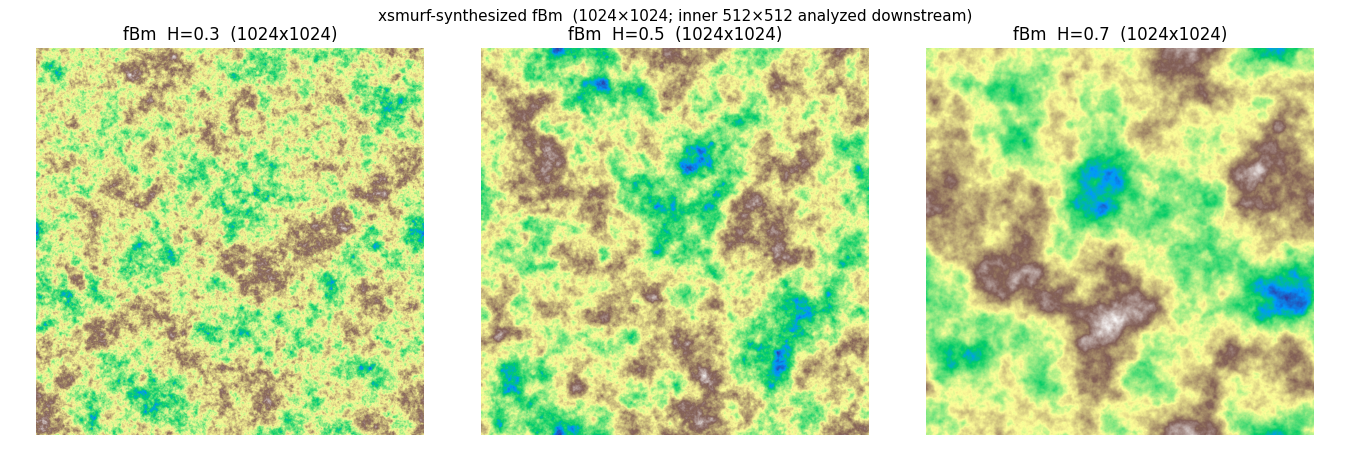

In [25]:
# ===== Synthesize fBm via xsmurf C code (`ibro`) at 1024×1024 per H =====
import os, subprocess
from pathlib import Path

XSMURF_BIN     = '/Users/amasaryk/projects/xSmurfMacPorts/xsmurf/main/xsmurf'
XSMURF_DEMO_DIR = Path('/Users/amasaryk/projects/xSmurfMacPorts/xsmurf/doc/templates/testXsmurf_scalar2d')
XSMURF_TCL_DIR = Path('/tmp/xsmurf_fbm_synth')
XSMURF_TCL_DIR.mkdir(exist_ok=True)

def load_xsm(path):
    """Load an xsmurf binary image (header line + raw float32)."""
    with open(path, 'rb') as f:
        header = f.readline().decode()
        parts  = header.split()                        # 'Binary 1 1024x1024 ...'
        lx, ly = (int(d) for d in parts[2].split('x'))
        data = np.frombuffer(f.read(), dtype=np.float32)
    return data.reshape(ly, lx)

def synth_fbm_via_xsmurf(H, size, out_path, seed=42, timeout=600):
    """Run xsmurf -nodisplay with a tiny TCL script that calls `ibro` and `isave`.
    Uses xsmurf's `im_construit_brownien_fft` (image/generator.c) for synthesis."""
    tcl_script = f'''ibro fbm {size} -h {H} -alea {seed}
isave fbm {out_path}
exit
'''
    script_path = XSMURF_TCL_DIR / f'synth_H{H}_n{size}.tcl'
    script_path.write_text(tcl_script)
    proc = subprocess.run([XSMURF_BIN, '-nodisplay', str(script_path)],
                           capture_output=True, text=True, timeout=timeout)
    return proc.returncode, (proc.stdout[-1500:] + '\n--- stderr ---\n'
                              + proc.stderr[-1500:])


# ---- Configuration: 1024 synth, analyze inner 512 (downstream cell sets WTMM_INNER_WINDOW=512) ----
FBM_SYNTH_SIZE = 1024
FBM_H_VALUES   = [0.3, 0.5, 0.7]

fbm_fields = {}
XSMURF_DEMO_LOADED = False

if Path(XSMURF_BIN).exists():
    print(f'Synthesizing fBm at {FBM_SYNTH_SIZE}x{FBM_SYNTH_SIZE} via xsmurf for '
          f'H in {FBM_H_VALUES}...')
    XSMURF_DEMO_LOADED = True
    for H in FBM_H_VALUES:
        out_path = XSMURF_TCL_DIR / f'fbm_H{H}_n{FBM_SYNTH_SIZE}.xsm'
        if not out_path.exists():
            seed = int(round(H * 1000))
            rc, log_tail = synth_fbm_via_xsmurf(H, FBM_SYNTH_SIZE, out_path, seed=seed)
            if rc != 0 or not out_path.exists():
                print(f'  H={H}: xsmurf synth failed (rc={rc})')
                print(log_tail)
                XSMURF_DEMO_LOADED = False
                break
        try:
            fbm_fields[H] = load_xsm(out_path)
            f = fbm_fields[H]
            print(f'  H={H}:  loaded {out_path.name}  shape {f.shape}  '
                   f'std={f.std():.4f}  range=[{f.min():.4f}, {f.max():.4f}]')
        except Exception as e:
            print(f'  H={H}: load failed ({e})')
            XSMURF_DEMO_LOADED = False
            break

if not XSMURF_DEMO_LOADED:
    print('\nFalling back to Python fBm synthesis at 1024.')
    FBM_SYNTH_SIZE = 1024
    for H in FBM_H_VALUES:
        fft_dim = 1024
        fbm_fields[H] = synthesize_fbm_xsmurf(FBM_SYNTH_SIZE, H,
                                                fft_dim=fft_dim,
                                                seed=int(round(H * 1000)))

# Visualize
fig, axs = plt.subplots(1, max(len(fbm_fields), 2),
                          figsize=(4.5 * max(len(fbm_fields), 2), 4.5),
                          squeeze=False)
for ax, (k, v) in zip(axs[0], fbm_fields.items()):
    ax.imshow(v, cmap='terrain'); ax.set_axis_off()
    ax.set_title(f'fBm  H={k}  ({v.shape[0]}x{v.shape[1]})')
fig.suptitle('xsmurf-synthesized fBm  (1024×1024; inner 512×512 analyzed downstream)',
              fontsize=11)
fig.tight_layout(); plt.show()


## WTMM pipeline (matches xsmurf demo `wtmmg` + `chain` + `pf compute`)

Parameters lifted from `parameters_gaussian.tcl` of xsmurf's scalar 2D demo (with our window size). `compute_HD_per_scale` produces `h(q, a)` and `D(q, a)` directly from extrema images — same recipe as `pf compute` in xsmurf TCL.


In [42]:
# Parameters mirroring xsmurf scalar 2D demo
WAVELET    = 'mexican'   # iwtmm always uses g1 (1st-deriv-of-Gaussian); xsmurf demo default
THRESH     = 1e-1
A_MIN      = 1.863
N_OCT      = 4
N_VOX      = 13
SIMILITUDE = 0.8
DIST_FRAC  = 0.1
BORDER_PCT = 2.0
INNER_WINDOW = 512
FRACINT_ALPHA = 0.0   # no fracint for fBm calibration; iwtmm handles via `eta=`

Q_LIST = np.arange(-3.0, 4.05, 0.25)

scales = compute_scales(n_oct=N_OCT, n_vox=N_VOX, a_min=A_MIN)
n_sc   = len(scales)
log2_s = np.log2(scales)
print(f'{n_sc} scales: {scales[0]:.2f} .. {scales[-1]:.2f} px')

fbm_results = {}
for H, field in fbm_fields.items():
    print(f'\n--- H = {H} ---')
    t0 = time.perf_counter()

    # xsmurf-internal CWT + extrema in ONE call
    # Uses xsmurf's gfft (FFTW3f), libmatheval-evaluated wavelet expression,
    # and im_mult_analog convolution + wtmm2d NMS extrema -- all in C.
    ext_result = xsm.iwtmm(field.astype(np.float32),
                            a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
                            method='wtmm2d', thresh=THRESH,
                            eta=FRACINT_ALPHA, verbose=False)
    ext_images = ext_result['ext_images']
    print(f'  xsm.iwtmm (FFTW+libmatheval): {(time.perf_counter()-t0)*1e3:.0f} ms, '
          f'{len(ext_images)} extrema images')

    chains = chain_and_extract(
        ext_images, scales, method='greedy',
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        similitude=SIMILITUDE, smooth=True,
        border_percent=BORDER_PCT, dist_frac=DIST_FRAC)

    # Inner-window filter (CWT was on full field; only chains in central
    # INNER_WINDOW have COI-clean wavelet support across all scales)
    if INNER_WINDOW is not None:
        ny_full, nx_full = field.shape
        if ny_full >= INNER_WINDOW + 64 and nx_full >= INNER_WINDOW + 64:
            cy, cx = ny_full // 2, nx_full // 2
            half = INNER_WINDOW // 2
            n_pre = len(chains)
            chains = [ch for ch in chains
                       if cy - half <= int(ch['y'][0]) < cy + half
                       and cx - half <= int(ch['x'][0]) < cx + half]
            print(f'  inner-window [{cy-half}:{cy+half}, {cx-half}:{cx+half}]: '
                   f'{n_pre} -> {len(chains)} chains')

    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders if np.isfinite(h['h'])]
    print(f'  per-chain h_median = {np.median(h_vals):+.3f}  (expected H = {H})')

    # Standard + chainmax partition functions, both using xsmurf-equivalent code
    hd_std  = compute_HD_per_scale(ext_images, scales, Q_LIST,
                                     on_vc_only=True)
    hd_cmax = compute_HD_per_scale(ext_images, scales, Q_LIST,
                                     on_vc_only=True,
                                     chains=chains, use_chainmax=True)

    fbm_results[H] = {
        'field': field, 'chains': chains, 'holders': holders,
        'ext_images': ext_images,
        'hd':       hd_std,    # back-compat alias
        'hd_std':   hd_std,
        'hd_cmax':  hd_cmax,
    }
print('\nDone.')


52 scales: 13.00 .. 197.16 px

--- H = 0.3 ---
  xsm.iwtmm (FFTW+libmatheval): 7291 ms, 52 extrema images
  inner-window [256:768, 256:768]: 6707 -> 1678 chains
  per-chain h_median = -0.320  (expected H = 0.3)

--- H = 0.5 ---
  xsm.iwtmm (FFTW+libmatheval): 7297 ms, 52 extrema images
  inner-window [256:768, 256:768]: 5583 -> 1417 chains
  per-chain h_median = -0.088  (expected H = 0.5)

--- H = 0.7 ---
  xsm.iwtmm (FFTW+libmatheval): 7224 ms, 52 extrema images
  inner-window [256:768, 256:768]: 4613 -> 1167 chains
  per-chain h_median = +0.115  (expected H = 0.7)

Done.


## τ(q,a), h(q,a), D(q,a) — static overlay (one panel per H)

Each panel shows `h(q, a)` vs `log₂ a` for several q values. **In the multifractal scaling regime, `h(q, a)` should be flat** (independent of a). The flat region IS the plateau you want to fit.


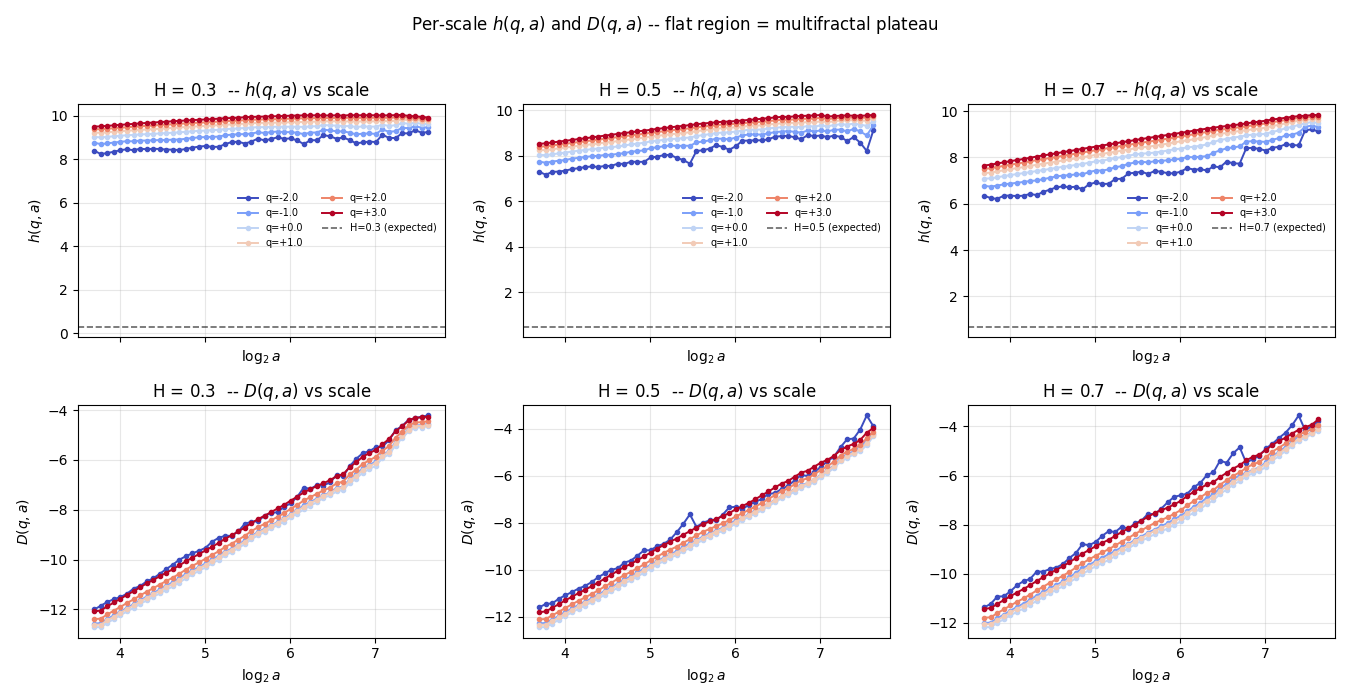

In [43]:
fig, axs = plt.subplots(2, len(FBM_H_VALUES),
                          figsize=(4.5 * len(FBM_H_VALUES), 7),
                          squeeze=False, sharex=True)
_q_show = [-2, -1, 0, 1, 2, 3]
_q_idxs = [int(np.argmin(np.abs(Q_LIST - q))) for q in _q_show]
_cmap   = plt.cm.coolwarm(np.linspace(0, 1, len(_q_show)))

for col, H in enumerate(FBM_H_VALUES):
    hd = fbm_results[H]['hd']
    h_qa = hd['h_qa']     # shape (n_q, n_sc)
    D_qa = hd['D_qa']
    ax = axs[0, col]
    for k, qi in enumerate(_q_idxs):
        ax.plot(log2_s, h_qa[qi], 'o-', color=_cmap[k], lw=1.4,
                  ms=3, label=f'q={Q_LIST[qi]:+.1f}')
    ax.axhline(H, color='black', lw=1.2, ls='--', alpha=0.6,
                label=f'H={H} (expected)')
    ax.set_xlabel(r'$\log_2 a$')
    ax.set_ylabel(r'$h(q, a)$')
    ax.set_title(f'H = {H}  -- $h(q, a)$ vs scale')
    ax.legend(fontsize=7, frameon=False, ncol=2)
    ax.grid(alpha=0.3)

    ax = axs[1, col]
    for k, qi in enumerate(_q_idxs):
        ax.plot(log2_s, D_qa[qi], 'o-', color=_cmap[k], lw=1.4,
                  ms=3, label=f'q={Q_LIST[qi]:+.1f}')
    ax.set_xlabel(r'$\log_2 a$')
    ax.set_ylabel(r'$D(q, a)$')
    ax.set_title(f'H = {H}  -- $D(q, a)$ vs scale')
    ax.grid(alpha=0.3)

fig.suptitle(r'Per-scale $h(q, a)$ and $D(q, a)$ -- flat region = multifractal plateau',
              fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


## Log-log chain viewer — xsmurf-style sheaf

Each chain plotted as `log₂|W|` vs `log₂ a`. Color = max local slope along the chain (a "kink" detector — clean power-law chains have max ≈ OLS h; chains with one anomalous step show much larger max than mean).

**For 2D fBm at Hurst H**: chains should align as a tight bundle of parallel lines with slope ≈ H. Outliers (chains diverging from the bundle) are candidates for hygiene pruning in the next cell.


interactive(children=(Dropdown(description='H:', index=1, options=(0.3, 0.5, 0.7), value=0.5), Output()), _dom…

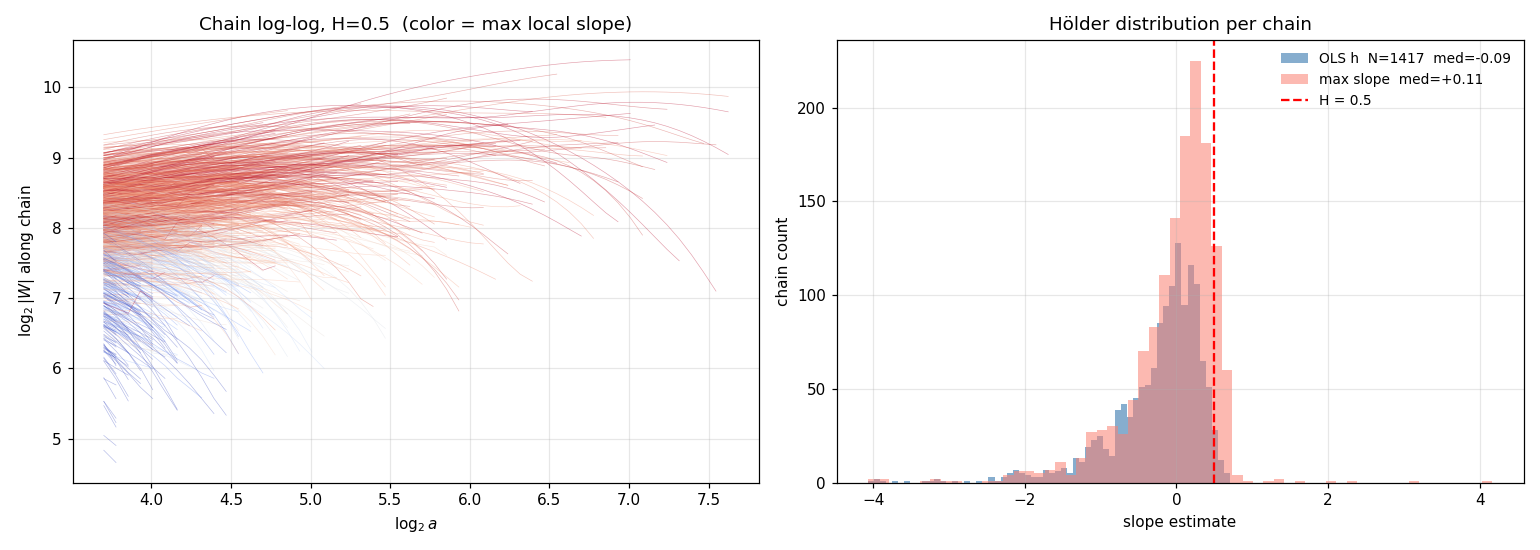

In [44]:
# ===== Log-log chain viewer (xsmurf-style sheaf) =====
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interactive, Dropdown

def _max_slope_chain(ch):
    log2s = np.asarray(ch['log2_scales'])
    log2m = np.asarray(ch['log2_mod'])
    if len(log2s) < 2: return np.nan
    ds = np.diff(log2s); dm = np.diff(log2m)
    sl = dm / np.where(np.abs(ds) > 1e-12, ds, np.nan)
    v  = np.isfinite(sl)
    return float(np.max(sl[v])) if v.any() else np.nan

_fig_ll, _ax_ll = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

def _draw_loglog(H_target):
    H_target = float(H_target)
    res = fbm_results[H_target]
    chs = res['chains']
    holders = res['holders']

    h_ols  = np.array([h['h'] for h in holders if np.isfinite(h['h'])])
    max_h  = np.array([_max_slope_chain(ch) for ch in chs])
    valid  = np.isfinite(max_h)

    for ax in _ax_ll: ax.cla()

    # Left: chain log-log, colored by max slope
    ax = _ax_ll[0]
    if valid.any():
        vmin, vmax = np.percentile(max_h[valid], [5, 95])
        denom = max(vmax - vmin, 1e-9)
        cap = min(2000, len(chs))
        for ch, mh in zip(chs[:cap], max_h[:cap]):
            if not np.isfinite(mh): continue
            color = plt.cm.coolwarm(np.clip((mh - vmin) / denom, 0, 1))
            ax.plot(ch['log2_scales'], ch['log2_mod'], '-',
                     color=color, lw=0.4, alpha=0.4)
    ax.set_xlabel(r'$\log_2 a$')
    ax.set_ylabel(r'$\log_2 |W|$ along chain')
    ax.set_title(f'Chain log-log, H={H_target}  (color = max local slope)')
    ax.grid(alpha=0.3)

    # Right: histograms of OLS h and max slope
    ax = _ax_ll[1]
    ax.hist(h_ols, bins=60, alpha=0.65,
              label=f'OLS h  N={len(h_ols)}  med={np.median(h_ols):+.2f}',
              color='steelblue')
    if valid.any():
        ax.hist(max_h[valid], bins=60, alpha=0.55,
                  label=f'max slope  med={np.median(max_h[valid]):+.2f}',
                  color='salmon')
    ax.axvline(H_target, color='red', lw=1.5, ls='--', label=f'H = {H_target}')
    ax.set_xlabel('slope estimate')
    ax.set_ylabel('chain count')
    ax.set_title('Hölder distribution per chain')
    ax.legend(fontsize=9, loc='best', frameon=False)
    ax.grid(alpha=0.3)

    _fig_ll.tight_layout()

_dd_ll = Dropdown(options=FBM_H_VALUES,
                    value=FBM_H_VALUES[len(FBM_H_VALUES) // 2],
                    description='H:')
interactive(_draw_loglog, H_target=_dd_ll)


## Chain pruning — minimum length + fine-scale-only slope filter

Two pre-specified hygiene rules:

1. **Min chain length**: drop chains spanning fewer than `PRUNE_MIN_SCALES` scales (length-1 and length-2 chains are unreliable for slope estimation).
2. **Fine-scale OLS slope filter**: refit each chain's `log₂|W|` vs `log₂ a` using **only the finest `PRUNE_FINE_N` scales**, then drop chains whose recovered slope falls outside `[PRUNE_SLOPE_MIN, PRUNE_SLOPE_MAX]`. Coarse scales get unstable in xsmurf-style chaining (boundary effects, chain death); the finest scales are where the slope is most physical.

Each H gets a side-by-side panel showing the fine-scale slope distribution before/after the slope filter, with the expected H marked.

Pruned chains are stored as `fbm_results[H]['chains_pruned']` and `holders_pruned` so downstream cells can opt into them.


Chain pruning  --  min_scales=1, fine_n=6,
                   slope range=[-0.5, 2.5]

  H=0.3:  1678 -> 1049 kept (63%)   OLS h_med -0.320 -> -0.160   fine-h_med -0.056
  H=0.5:  1417 -> 1018 kept (72%)   OLS h_med -0.088 -> +0.011   fine-h_med +0.073
  H=0.7:  1167 -> 920 kept (79%)   OLS h_med +0.115 -> +0.172   fine-h_med +0.223


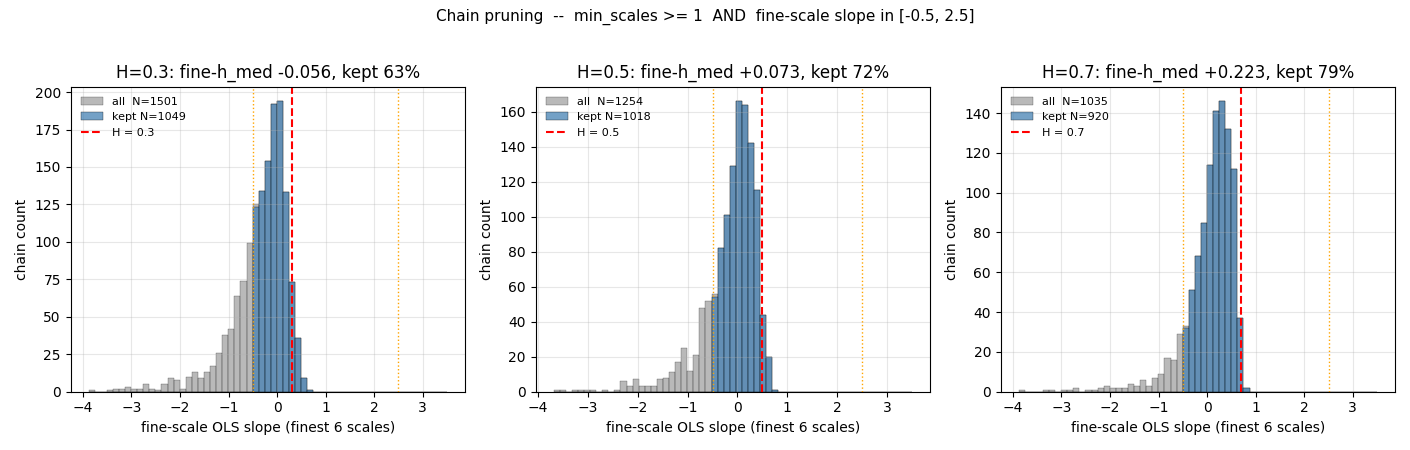

In [47]:
# ===== Chain pruning =====
import numpy as np
import matplotlib.pyplot as plt

PRUNE_MIN_SCALES = 1       # chain must span >= this many scales
PRUNE_FINE_N     = 6         # number of FINEST scales used for slope fit
PRUNE_SLOPE_MIN  = -.5  # 2D math floor with safety margin
PRUNE_SLOPE_MAX  = 2.5       # well above any reasonable Hölder for H<=1

def _fine_scale_slope(ch, n_fine):
    log2_s = np.asarray(ch['log2_scales'])
    log2_m = np.asarray(ch['log2_mod'])
    if len(log2_s) < 3:
        return np.nan, np.nan
    order = np.argsort(log2_s)
    log2_s = log2_s[order]; log2_m = log2_m[order]
    n_use = min(len(log2_s), n_fine)
    log2_s = log2_s[:n_use]; log2_m = log2_m[:n_use]
    coef   = np.polyfit(log2_s, log2_m, 1)
    h_fit  = float(coef[0])
    fit    = np.polyval(coef, log2_s)
    ss_res = float(np.sum((log2_m - fit) ** 2))
    ss_tot = float(np.sum((log2_m - log2_m.mean()) ** 2))
    r2     = 1.0 - ss_res / max(ss_tot, 1e-30) if ss_tot > 1e-30 else np.nan
    return h_fit, float(r2)

print(f'Chain pruning  --  min_scales={PRUNE_MIN_SCALES}, fine_n={PRUNE_FINE_N},')
print(f'                   slope range=[{PRUNE_SLOPE_MIN}, {PRUNE_SLOPE_MAX}]')
print()

n_h = len(FBM_H_VALUES)
fig, axs = plt.subplots(1, n_h, figsize=(4.7 * n_h, 4.5), squeeze=False)

for ax, H in zip(axs[0], FBM_H_VALUES):
    res     = fbm_results[H]
    chs     = res['chains']
    holders = res['holders']
    n_pre   = len(chs)

    keep_mask  = np.zeros(n_pre, dtype=bool)
    fine_h     = np.full(n_pre, np.nan)
    fine_r2    = np.full(n_pre, np.nan)
    n_scales_a = np.zeros(n_pre, dtype=int)

    for i, ch in enumerate(chs):
        n_scales_a[i] = len(ch['log2_scales'])
        if n_scales_a[i] < PRUNE_MIN_SCALES:
            continue
        h_fit, r2 = _fine_scale_slope(ch, PRUNE_FINE_N)
        fine_h[i]  = h_fit
        fine_r2[i] = r2
        if (np.isfinite(h_fit) and PRUNE_SLOPE_MIN <= h_fit <= PRUNE_SLOPE_MAX):
            keep_mask[i] = True

    chs_pruned     = [ch for ch, k in zip(chs, keep_mask) if k]
    holders_pruned = [h for h, k in zip(holders, keep_mask) if k]
    n_post         = len(chs_pruned)

    h_pre  = float(np.median([h['h'] for h in holders if np.isfinite(h['h'])]))
    h_post = float(np.median([h['h'] for h in holders_pruned
                                 if np.isfinite(h['h'])])) if holders_pruned else np.nan
    h_fine_post = float(np.nanmedian(fine_h[keep_mask]))

    print(f'  H={H}:  '
           f'{n_pre} -> {n_post} kept ({100*n_post/max(n_pre,1):.0f}%)   '
           f'OLS h_med {h_pre:+.3f} -> {h_post:+.3f}   '
           f'fine-h_med {h_fine_post:+.3f}')

    valid = np.isfinite(fine_h)
    bins = np.linspace(min(PRUNE_SLOPE_MIN - 1, np.nanmin(fine_h)) if valid.any() else -3,
                         max(PRUNE_SLOPE_MAX + 1, np.nanmax(fine_h)) if valid.any() else 3,
                         60)
    ax.hist(fine_h[valid], bins=bins, alpha=0.55, color='gray',
              label=f'all  N={int(valid.sum())}', edgecolor='black', lw=0.3)
    ax.hist(fine_h[valid & keep_mask], bins=bins, alpha=0.75, color='steelblue',
              label=f'kept N={n_post}', edgecolor='black', lw=0.3)
    ax.axvline(H, color='red', lw=1.5, ls='--', label=f'H = {H}')
    ax.axvline(PRUNE_SLOPE_MIN, color='orange', lw=1, ls=':')
    ax.axvline(PRUNE_SLOPE_MAX, color='orange', lw=1, ls=':')
    ax.set_xlabel(f'fine-scale OLS slope (finest {PRUNE_FINE_N} scales)')
    ax.set_ylabel('chain count')
    ax.set_title(f'H={H}: fine-h_med {h_fine_post:+.3f}, kept {100*n_post/max(n_pre,1):.0f}%')
    ax.legend(fontsize=8, loc='best', frameon=False)
    ax.grid(alpha=0.3)

    res['chains_pruned']  = chs_pruned
    res['holders_pruned'] = holders_pruned
    res['fine_h']         = fine_h
    res['fine_r2']        = fine_r2
    res['n_scales_arr']   = n_scales_a

fig.suptitle(f'Chain pruning  --  min_scales >= {PRUNE_MIN_SCALES}  AND  '
              f'fine-scale slope in [{PRUNE_SLOPE_MIN}, {PRUNE_SLOPE_MAX}]',
              fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


## Interactive plateau fitter

Range slider picks the scale plateau; switch H via dropdown; live update of `τ(q)`, `h(q)`, `D(h)` from the chosen plateau. **Watch:** with the right plateau choice, `h(q)` should sit on a horizontal line at H, and `D(h)` should be a narrow peak centered at H.


interactive(children=(Dropdown(description='H:', index=1, options=(0.3, 0.5, 0.7), value=0.5), FloatRangeSlide…

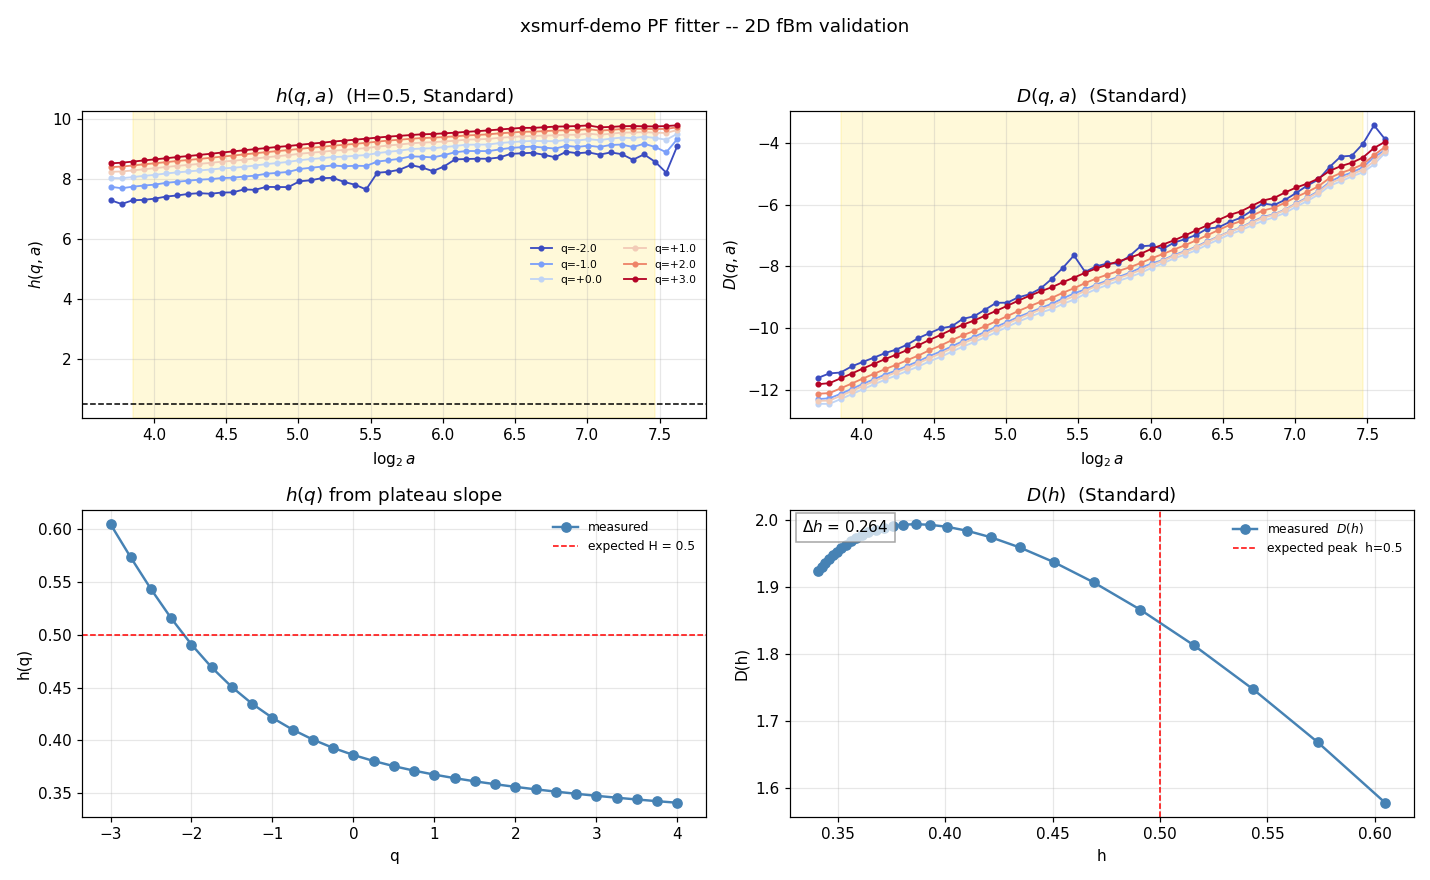

In [48]:
from ipywidgets import interactive, Dropdown, FloatRangeSlider, ToggleButtons
import matplotlib.pyplot as plt
import numpy as np

_fig_pf, _axes_pf = plt.subplots(2, 2, figsize=(13, 8), dpi=110)

def _fit_slope_vectorized(Y_qa, mask, log2_s):
    """Vectorized OLS slope of Y_qa[:, mask] vs log2_s[mask] for all q at once.
    Returns (slope_q, intercept_q) shape (n_q,).  ~50x faster than per-q loop."""
    x  = log2_s[mask]
    Y  = Y_qa[:, mask]                       # (n_q, n_in)
    xc = x - x.mean()
    yc = Y - Y.mean(axis=-1, keepdims=True)
    denom = float((xc * xc).sum())
    if denom <= 0: return np.full(Y.shape[0], np.nan), np.full(Y.shape[0], np.nan)
    slope = (yc * xc[None, :]).sum(axis=-1) / denom
    inter = Y.mean(axis=-1) - slope * x.mean()
    return slope, inter

def _draw_pf(H_target, scale_range_log2, pf_mode):
    H_target = float(H_target)
    res = fbm_results[H_target]
    hd  = res["hd_cmax"] if pf_mode == "Chainmax" else res["hd_std"]
    log2_s_arr = hd["log2_scales"]
    s_lo, s_hi = 2.0 ** scale_range_log2[0], 2.0 ** scale_range_log2[1]
    fit_mask = (hd["scales"] >= s_lo) & (hd["scales"] <= s_hi)

    # Fully vectorized OLS for tau, h, D (single matrix op per panel)
    tau_q, _ = _fit_slope_vectorized(hd["tau_qa"], fit_mask, log2_s_arr)
    h_q,   _ = _fit_slope_vectorized(hd["h_qa"],   fit_mask, log2_s_arr)
    D_q,   _ = _fit_slope_vectorized(hd["D_qa"],   fit_mask, log2_s_arr)

    for ax in _axes_pf.ravel(): ax.cla()

    # Panel (0,0): h(q, a) traces
    ax = _axes_pf[0, 0]
    h_qa = hd["h_qa"]
    for k, qi in enumerate(_q_idxs):
        ax.plot(log2_s_arr, h_qa[qi], "o-", color=_cmap[k], lw=1.2,
                  ms=3, label=f"q={Q_LIST[qi]:+.1f}")
    ax.axvspan(np.log2(s_lo), np.log2(s_hi), alpha=0.15, color="gold")
    ax.axhline(H_target, color="k", lw=1, ls="--")
    ax.set_xlabel(r"$\log_2 a$"); ax.set_ylabel(r"$h(q, a)$")
    ax.set_title(f"$h(q, a)$  (H={H_target}, {pf_mode})")
    ax.legend(fontsize=7, frameon=False, ncol=2); ax.grid(alpha=0.3)

    # Panel (0,1): D(q, a) traces
    ax = _axes_pf[0, 1]
    D_qa = hd["D_qa"]
    for k, qi in enumerate(_q_idxs):
        ax.plot(log2_s_arr, D_qa[qi], "o-", color=_cmap[k], lw=1.2, ms=3)
    ax.axvspan(np.log2(s_lo), np.log2(s_hi), alpha=0.15, color="gold")
    ax.set_xlabel(r"$\log_2 a$"); ax.set_ylabel(r"$D(q, a)$")
    ax.set_title(f"$D(q, a)$  ({pf_mode})")
    ax.grid(alpha=0.3)

    # Panel (1,0): h(q) from plateau
    ax = _axes_pf[1, 0]
    ax.plot(Q_LIST, h_q, "o-", color="steelblue", lw=1.6, label="measured")
    ax.axhline(H_target, color="red", lw=1, ls="--",
                label=f"expected H = {H_target}")
    ax.set_xlabel("q"); ax.set_ylabel("h(q)")
    ax.set_title(r"$h(q)$ from plateau slope")
    ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)

    # Panel (1,1): D(h)
    ax = _axes_pf[1, 1]
    valid = np.isfinite(h_q) & np.isfinite(D_q)
    ax.plot(h_q[valid], D_q[valid], "o-", color="steelblue", lw=1.6,
             label="measured  $D(h)$")
    ax.axvline(H_target, color="red", lw=1, ls="--",
                label=f"expected peak  h={H_target}")
    if valid.sum() >= 3:
        dh = float(np.nanmax(h_q[valid]) - np.nanmin(h_q[valid]))
        ax.text(0.02, 0.97, fr"$\Delta h$ = {dh:.3f}",
                  transform=ax.transAxes, va="top",
                  bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"))
    ax.set_xlabel("h"); ax.set_ylabel("D(h)")
    ax.set_title(f"$D(h)$  ({pf_mode})")
    ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)

    _fig_pf.suptitle(r"xsmurf-demo PF fitter -- 2D fBm validation",
                       fontsize=12)
    _fig_pf.tight_layout(rect=[0, 0, 1, 0.96])

_H_dd     = Dropdown(options=FBM_H_VALUES, value=FBM_H_VALUES[len(FBM_H_VALUES) // 2],
                       description="H:")
_pf_tog   = ToggleButtons(options=["Standard", "Chainmax"], value="Standard",
                            description="Mode:")
_scale_rs = FloatRangeSlider(
    value=(np.log2(scales[2]), np.log2(scales[-3])),
    min=float(np.log2(scales[0])), max=float(np.log2(scales[-1])),
    step=0.1, description="log2(a) plateau:",
    style={"description_width": "initial"})

interactive(_draw_pf, H_target=_H_dd, scale_range_log2=_scale_rs, pf_mode=_pf_tog)


## Calibration summary

Compare measured `h_median` to expected `H` across the three test fBm fields. **If the bias is < 0.05**, xsmurf normalization is L¹ and your data-pipeline Hölder values are correct as measured. If consistently `~+1`, there's an L² leak.


In [ ]:
print(f'{"H":>4s}  {"h_median (chain)":>18s}  {"bias":>8s}  N_chains')
print('-' * 52)
for H in FBM_H_VALUES:
    holders = fbm_results[H]['holders']
    h_vals  = np.array([h['h'] for h in holders if np.isfinite(h['h'])])
    h_med   = float(np.median(h_vals)) if h_vals.size else np.nan
    print(f'{H:>4.1f}  {h_med:>+18.4f}  {h_med - H:>+8.4f}  {len(h_vals)}')
print('-' * 52)
print('Verdict: bias <= 0.05 -> L¹ normalization confirmed.')
print('         bias ~ +1   -> L² leak; subtract +1 from data h values.')
